In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

data = pd.read_csv('creditcard.csv')

data.head() # show first 5 rows

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


/var/folders/5j/3cg_lmv92tg3w0p4f58vz0pr0000gn/T/ipykernel_60738/2532314534.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  count_classes = pd.value_counts(data['Class'], sort=True).sort_index()


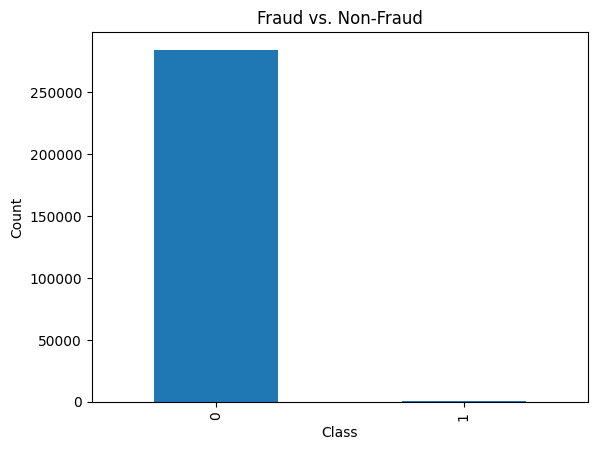

In [2]:
count_classes = pd.value_counts(data['Class'], sort=True).sort_index()
count_classes.plot(kind='bar')
plt.title('Fraud vs. Non-Fraud')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

In [3]:
from sklearn.preprocessing import StandardScaler

data['normAmount'] = StandardScaler().fit_transform(data['Amount'].values.reshape(-1, 1))
data = data.drop(['Time', 'Amount'], axis=1)
data.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Class,normAmount
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,0.244964
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.342475
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,1.160686
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,0.140534
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,-0.073403


In [ ]:
# get the class data
X = data.iloc[:, data.columns != 'Class']
y = data.iloc[:, data.columns == 'Class']

# count the number of fraud records
number_records_fraud = len(data[data.Class == 1])
fraud_indices = np.array(data[data.Class == 1].index)

# plan to select the same number of normal records as fraud records
normal_indices = data[data.Class == 0].index 
random_normal_indices = np.random.choice(normal_indices, number_records_fraud, replace=False)
random_normal_indices = np.array(random_normal_indices)

# create the under-sampled data set
under_sample_indices = np.concatenate([fraud_indices, random_normal_indices])
under_sample_data = data.iloc[under_sample_indices, :] 

X_under_sample = under_sample_data.iloc[:, under_sample_data.columns != 'Class']
y_under_sample = under_sample_data.iloc[:, under_sample_data.columns == 'Class']

print(" normal records rate: ",len(under_sample_data[under_sample_data.Class == 0]) / len(under_sample_data))
print(" fraud records rate:", len(under_sample_data[under_sample_data.Class == 1]) / len(under_sample_data))
print(" under_sample data length: ", len(under_sample_data))


 normal records rate:  0.5
 fraud records rate: 0.5
 under_sample data length:  984


In [7]:
from sklearn.model_selection import train_test_split

# raw data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
# under_sample data
X_train_undersample, X_test_undersample, y_train_undersample, y_test_undersample = train_test_split(X_under_sample, y_under_sample, test_size=0.3, random_state=0)


In [11]:
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import recall_score

fold = KFold(n_splits=5, shuffle=False)
recall_accs = []

for iteration, (train_index, val_index) in enumerate(fold.split(X_train_undersample)):

    # 1. create a new model for each fold
    lr = LogisticRegression(C=0.01, penalty='l1', solver='liblinear')

    # 2. train the model on the training data
    lr.fit(X_train_undersample.iloc[train_index, :],
            y_train_undersample.iloc[train_index].values.ravel())
    
    # 3. predict 
    y_pred = lr.predict(X_train_undersample.iloc[val_index, :].values)

    # 4. calculate recall
    recall = recall_score(y_train_undersample.iloc[val_index, :].values, y_pred)
    recall_accs.append(recall)

    print(f'Fold {iteration+1}: Recall = {recall:.4f}')

print(f"----------------------")
print(f"Average recall = { np.mean(recall_accs) }")

Fold 1: Recall = 0.9315
Fold 2: Recall = 0.9178
Fold 3: Recall = 1.0000
Fold 4: Recall = 0.9730
Fold 5: Recall = 0.9697
----------------------
Average recall = 0.9583970022326186


/Users/apple/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Users/apple/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Users/apple/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Users/apple/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Users/apple/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with f

In [13]:
from sklearn.model_selection import cross_val_score

lr = LogisticRegression(C=0.01, penalty='l1', solver='liblinear')
scores = cross_val_score(lr, X_train_undersample, y_train_undersample.values.ravel(), cv=5, scoring='recall')

print(scores)
print(scores.mean())

[0.94202899 0.91304348 0.98550725 0.97101449 0.97101449]
0.9565217391304348


In [16]:
# Logistic Regression and Regularized parameter selection

from sklearn.metrics import recall_score

def printing_Kfold_scores(x_train_data, y_train_data):

    fold = KFold(n_splits=5, shuffle=False)
    c_param_range = [0.01, 0.1, 1, 10, 100]

    results_table = pd.DataFrame(index=range(len(c_param_range)),
    columns=['C_parameter', 'Mean recall score'])

    results_table['C_parameter'] = c_param_range
    j = 0

    for c_param in c_param_range:
        print('---------------')
        print('C parameter:', c_param)
        recall_accs = []

        for iteration, (train_index, val_index) in enumerate(fold.split(x_train_data), start=1):

            lr = LogisticRegression(C=c_param, penalty='l1', solver='liblinear')
            lr.fit(x_train_data.iloc[train_index, :],
                y_train_data.iloc[train_index, :].values.ravel())
            y_pred = lr.predict(x_train_data.iloc[val_index, :].values)

            recall_acc = recall_score(y_train_data.iloc[val_index, :].values, y_pred)
            recall_accs.append(recall_acc)
            print('Iteration', iteration, 'recall score:', recall_acc)
        
        mean_recall = np.mean(recall_accs)
        results_table.loc[j, 'Mean recall score'] = mean_recall
        j += 1
        print(f"mean recall = {mean_recall}")
    
    # select the best C parameter
    best_c = results_table.loc[results_table['Mean recall score'].astype('float64').idxmax()]['C_parameter']

    print('Best C parameter:', best_c)
    return best_c

best_c = printing_Kfold_scores(X_train_undersample, y_train_undersample) # call the function


---------------
C parameter: 0.01
Iteration 1 recall score: 0.9315068493150684
Iteration 2 recall score: 0.9178082191780822
Iteration 3 recall score: 1.0
Iteration 4 recall score: 0.972972972972973
Iteration 5 recall score: 0.9696969696969697
mean recall = 0.9583970022326186
---------------
C parameter: 0.1
Iteration 1 recall score: 0.8493150684931506
Iteration 2 recall score: 0.863013698630137
Iteration 3 recall score: 0.9322033898305084
Iteration 4 recall score: 0.9459459459459459
Iteration 5 recall score: 0.9090909090909091
mean recall = 0.8999138023981302
---------------
C parameter: 1
Iteration 1 recall score: 0.863013698630137
Iteration 2 recall score: 0.8904109589041096
Iteration 3 recall score: 0.9661016949152542
Iteration 4 recall score: 0.9459459459459459
Iteration 5 recall score: 0.9242424242424242
mean recall = 0.9179429445275742
---------------
C parameter: 10
Iteration 1 recall score: 0.863013698630137
Iteration 2 recall score: 0.8904109589041096
Iteration 3 recall score:

/Users/apple/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Users/apple/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Users/apple/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Users/apple/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Users/apple/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with f

Iteration 3 recall score: 0.9661016949152542
Iteration 4 recall score: 0.9459459459459459
Iteration 5 recall score: 0.9242424242424242
mean recall = 0.9179429445275742
Best C parameter: 0.01


/Users/apple/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Users/apple/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Users/apple/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [23]:
from sklearn.model_selection import GridSearchCV

param_grid = {'C': [0.01, 0.1, 1, 10, 100]}
grid = GridSearchCV(LogisticRegression(penalty='l1', solver='liblinear'), param_grid, cv=5, scoring='recall')

grid.fit(X_train_undersample, y_train_undersample.values.ravel())

print(grid.best_params_)
print(grid.best_score_)
print(pd.DataFrame(grid.cv_results_)[['param_C', 'mean_test_score']])

{'C': 0.01}
0.9565217391304348
   param_C  mean_test_score
0     0.01         0.956522
1     0.10         0.898551
2     1.00         0.915942
3    10.00         0.915942
4   100.00         0.918841


In [ ]:
from sklearn.metrics import recall_score, precision_score, f1_score, classification_report

lr = LogisticRegression(C=best_c, penalty='l1', solver='liblinear')
lr.fit(X_train_undersample, y_train_undersample.values.ravel())

y_pred = lr.predict(X_test.values)

print('Recall:', recall_score(y_test, y_pred))
print('Precision:', precision_score(y_test, y_pred))
# F1 score is very bad
print('F1 Score:', f1_score(y_test, y_pred))
print('Classification Report:\n', classification_report(y_test, y_pred))

Recall: 0.9251700680272109
Precision: 0.013049318748800614
F1 Score: 0.025735641971804335
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.88      0.94     85296
           1       0.01      0.93      0.03       147

    accuracy                           0.88     85443
   macro avg       0.51      0.90      0.48     85443
weighted avg       1.00      0.88      0.93     85443



/Users/apple/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [27]:
# confusion 
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

recall = cm[1, 1] / (cm[1, 1] + cm[1, 0])
print(recall)

[[75010 10286]
 [   11   136]]
0.9251700680272109
